In [25]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.datasets import mnist


In [26]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


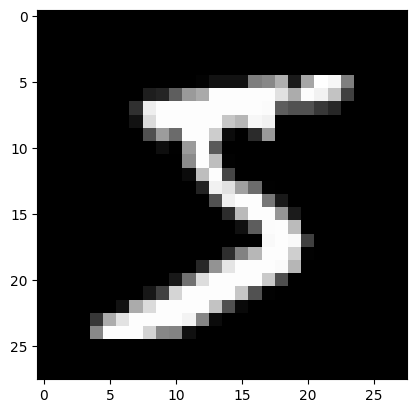

In [27]:
plt.imshow(x_train[0], cmap='gray')
plt.show()

In [28]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [29]:
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)


X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape : (10000, 28, 28)
y_test shape : (10000,)


In [30]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

In [31]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [32]:
x_train /= 255
x_test /= 255

In [33]:
# =====================================================
# One Hot Encoding
# =====================================================

# Number of output classes
num_classes = 10
y_train = np.eye(num_classes)[y_train]
y_test = np.eye(num_classes)[y_test]

In [34]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dropout(0.2),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=RMSprop(),
    metrics=['accuracy']
)

In [36]:
batch_size = 128
epochs = 20

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(x_test, y_test)
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9211 - loss: 0.2563 - val_accuracy: 0.9639 - val_loss: 0.1116
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9681 - loss: 0.1045 - val_accuracy: 0.9719 - val_loss: 0.0874
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9774 - loss: 0.0752 - val_accuracy: 0.9791 - val_loss: 0.0692
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9816 - loss: 0.0587 - val_accuracy: 0.9739 - val_loss: 0.0822
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9849 - loss: 0.0480 - val_accuracy: 0.9807 - val_loss: 0.0630
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9873 - loss: 0.0384 - val_accuracy: 0.9834 - val_loss: 0.0567
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9891 - loss: 0.0343 - val_accuracy: 0.9811 - val_loss: 0.0693
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9905 - loss: 0.0288 - v

In [37]:
score = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss    :", score[0])
print("Test Accuracy:", score[1])

Test Loss    : 0.08759111166000366
Test Accuracy: 0.9853000044822693


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


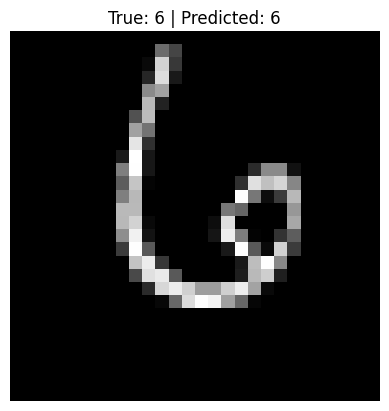

Confidence scores for all 10 digits: 
[[1.4828593e-08 2.8290982e-13 1.3773396e-12 4.0162741e-14 7.8983725e-10
  9.1089056e-09 1.0000000e+00 6.9654981e-12 8.0679613e-10 2.1984681e-13]]


In [38]:
import random

# 1. Select a random index from the test set
random_idx = random.randint(0, len(x_test) - 1)

# 2. Grab the image and its true label
# Note: We use the original reshaped data (1, 784)
sample_image = x_test[random_idx].reshape(1, 784)
true_label = np.argmax(y_test[random_idx])

# 3. Get the model's prediction
prediction = model.predict(sample_image)
predicted_label = np.argmax(prediction)

# 4. Display the result
plt.imshow(x_test[random_idx].reshape(28, 28), cmap='gray')
plt.title(f"True: {true_label} | Predicted: {predicted_label}")
plt.axis('off')
plt.show()

print(f"Confidence scores for all 10 digits: \n{prediction}")